In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

### 1. Load Dataset

In [2]:
sys.path.append(os.path.abspath(".."))

from src.db_connection import get_engine
engine = get_engine()

df = pd.read_sql("""
SELECT *
FROM vw_applications_ml_base
""", engine)

print(df.shape)
df.head()

(239660, 20)


,appid,name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,created_at,updated_at
0,10,Counter-Strike,game,0,0,2000-11-01,88.0,161854.0,999.0,999.0,0.0,USD,NaN,1,1,1,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,0,0,1999-04-01,NaN,6633.0,499.0,499.0,0.0,USD,NaN,1,1,1,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,0,0,2003-05-01,79.0,4308.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,0,0,2001-06-01,NaN,2338.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,0,0,1999-11-01,NaN,22793.0,499.0,499.0,0.0,USD,NaN,1,1,1,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


### 2. Overview Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239660 entries, 0 to 239659
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   appid                  239660 non-null  int64  
 1   name                   239660 non-null  str    
 2   type                   236993 non-null  str    
 3   is_free                239660 non-null  int64  
 4   required_age           239660 non-null  str    
 5   release_date           202809 non-null  str    
 6   metacritic_score       5299 non-null    float64
 7   recommendations_total  22560 non-null   float64
 8   mat_initial_price      144923 non-null  float64
 9   mat_final_price        144923 non-null  float64
 10  mat_discount_percent   144923 non-null  float64
 11  mat_currency           144923 non-null  str    
 12  mat_achievement_count  61401 non-null   float64
 13  mat_supports_windows   239660 non-null  int64  
 14  mat_supports_mac       239660 non-null  int64  

### 3. Missing Values Analysis

In [4]:
missing = df.isnull().sum()

missing_percent = (
    missing / len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df = missing_df.sort_values(
    by='Missing %',
    ascending=False
)

missing_df.head(15)

,Missing Count,Missing %
metacritic_score,234361,97.788951
recommendations_total,217100,90.586664
mat_achievement_count,178259,74.379955
mat_final_price,94737,39.529750
mat_discount_percent,94737,39.529750
mat_currency,94737,39.529750
mat_initial_price,94737,39.529750
release_date,36851,15.376367
supported_languages,17656,7.367103
short_description,15490,6.463323


### 4. Visualization Missing Data

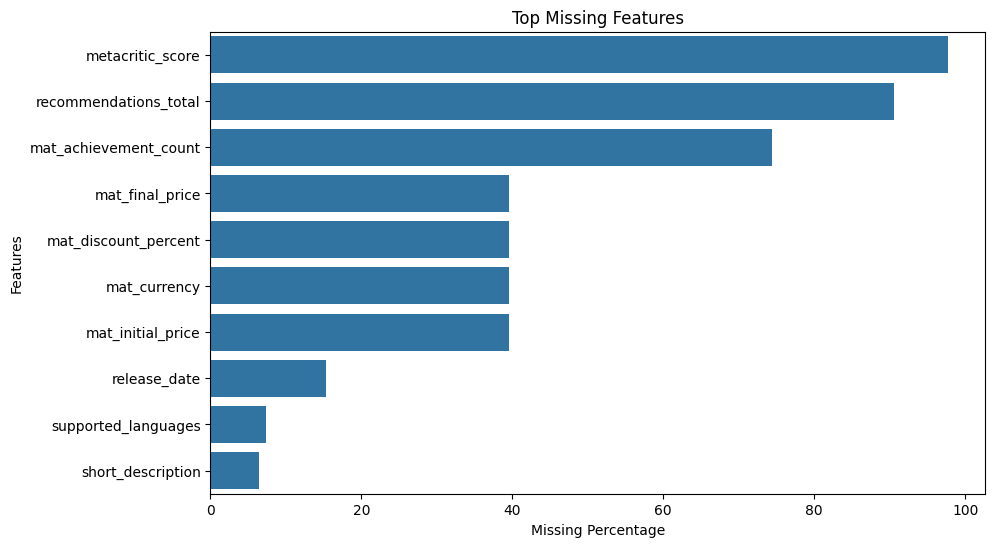

In [5]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_df.head(10)['Missing %'],
    y=missing_df.head(10).index
)

plt.title("Top Missing Features")
plt.xlabel("Missing Percentage")
plt.ylabel("Features")

plt.show()

### 5. Bias Analysis
- Ví dụ:

    - Linux games ít hơn Windows
    - Có thể gây bias model

In [6]:
platform_counts = {
    'Windows': df['mat_supports_windows'].sum(),
    'Mac': df['mat_supports_mac'].sum(),
    'Linux': df['mat_supports_linux'].sum()
}

platform_df = pd.DataFrame({
    'Platform': platform_counts.keys(),
    'Count': platform_counts.values()
})

platform_df

,Platform,Count
0,Windows,239654
1,Mac,239388
2,Linux,239360


### 6. Visualization Bias

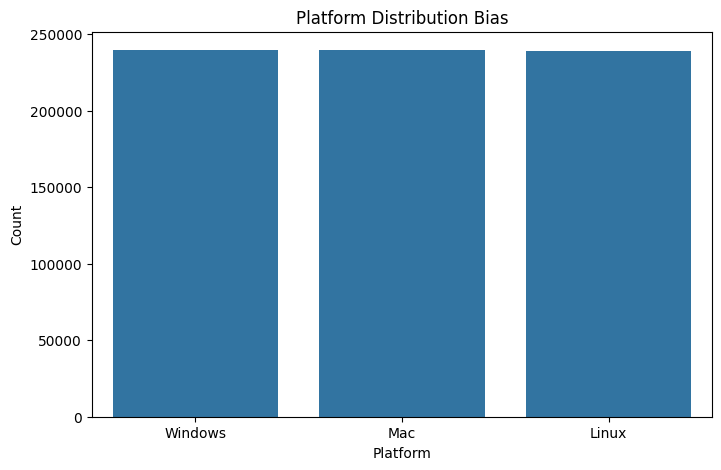

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Platform',
    y='Count',
    data=platform_df
)

plt.title("Platform Distribution Bias")

plt.show()

### 7. Phân tích về đạo đức AI

#### Các vấn đề đạo đức được nhận diện

##### 1. Mất cân bằng dữ liệu

- Các game hỗ trợ Windows chiếm phần lớn dataset.
- Game hỗ trợ Linux và Mac xuất hiện ít hơn.
- Điều này có thể khiến mô hình học máy bị thiên lệch.

##### 2. Dữ liệu thiếu

- Nhiều thuộc tính có tỷ lệ missing value rất cao.
- Một số game không có điểm Metacritic hoặc số lượng recommendations.
- Điều này ảnh hưởng đến chất lượng mô hình.

##### 3. Thiên lệch độ phổ biến

- Các game nổi tiếng thường nhận được nhiều đánh giá hơn.
- Các game indie nhỏ có thể bị mô hình đánh giá thấp.

##### 4. Rủi ro từ hệ thống tự động

- Hệ thống recommendation có thể ưu tiên các game đã nổi tiếng.
- Game mới sẽ khó được đề xuất hơn.

##### 5. Quyền riêng tư dữ liệu

- Dataset không chứa dữ liệu cá nhân nhạy cảm của người dùng.
- Rủi ro về quyền riêng tư tương đối thấp.

### 8. Fairness & Responsible AI

##### Tính công bằng và AI có trách nhiệm

- Hệ thống Machine Learning không nên chỉ ưu tiên các game phổ biến.

- Cần kiểm tra và giảm thiểu **platform bias** trong quá trình huấn luyện mô hình.

- Dataset cân bằng sẽ giúp mô hình công bằng hơn.

- Các phương pháp giải thích mô hình giúp tăng:
  - Tính minh bạch
  - Khả năng giải thích
  - Độ tin cậy của AI

- Một hệ thống AI có trách nhiệm cần đảm bảo:
  - Công bằng
  - Minh bạch
  - Trách nhiệm giải trình
  - Chất lượng dữ liệu

### 9. Hạn chế của Project

##### 1. Dataset chứa nhiều dữ liệu thiếu.
##### 2. Một số feature engineering còn đơn giản.
##### 3. Các đặc trưng dạng text chưa được xử lý chuyên sâu.
##### 4. Dataset chưa phản ánh đầy đủ toàn bộ hệ sinh thái Steam.
##### 5. Giới hạn tài nguyên tính toán nên chưa sử dụng các mô hình deep learning lớn.


### KẾT LUẬN TỔNG THỂ


- Bộ dữ liệu Steam Games cung cấp nhiều thông tin hữu ích
  phục vụ cho bài toán ML và phân tích dữ liệu.

- Tuy nhiên, dataset vẫn tồn tại nhiều vấn đề như:
    + dữ liệu thiếu
    + mất cân bằng nền tảng
    + thiên lệch độ phổ biến

- Việc phân tích đạo đức AI giúp:
    + tăng tính minh bạch
    + cải thiện độ tin cậy
    + đảm bảo tính công bằng của mô hình

- Responsible AI là yếu tố quan trọng trong
  các hệ thống machine learning hiện đại.